# CSE 413: Simulation and Modeling Lab
**Lab Performance 03: Two-Sample t-Test Hypothesis Testing & Confidence Interval Estimation**  
**Level / Term:** 4/1 | **Credit:** 1.5  
**Course Instructor:** Afroja Ahmed Smrity  
**Student Name:** Azhar  
**Student ID:** 1120  

---


## Problem Statement & Objectives

**Problem Statement:**  
Perform a two-sample t-test on the following independent datasets:
- **Data 1:** `[18.4, 19.1, 17.9, 18.7, 18.3]`
- **Data 2:** `[20.2, 20.5, 20.1, 20.3, 20.4]`

Use significance level **$\alpha = 0.05$** to determine whether the population means differ. Assume **equal population variances** (pooled variance approach).

### Assigned Tasks
1. State the null hypothesis ($H_0$) and alternative hypothesis ($H_1$).
2. Compute the sample means, sample variances ($ddof = 1$), and mean difference.
3. Calculate the degrees of freedom, pooled variance, standard error, $t$-statistic, and two-tailed $p$-value (both analytically and via `scipy.stats.ttest_ind`).
4. Construct the 95% confidence interval for the true mean difference $(\mu_1 - \mu_2)$.
5. Provide a statistical decision and clear plain-English interpretation.
6. Visualize the sample means with error bars and individual observation points.


In [1]:
# Import required scientific and visualization libraries
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


---
## Task 1: Hypothesis Formulation

We formulate the two-tailed hypothesis test as follows:
- **Null Hypothesis ($H_0$):** $\mu_1 = \mu_2$ (or $\mu_1 - \mu_2 = 0$)  
  *There is no statistically significant difference between the true population means of Data 1 and Data 2.*
- **Alternative Hypothesis ($H_1$):** $\mu_1 \neq \mu_2$ (or $\mu_1 - \mu_2 \neq 0$)  
  *There is a statistically significant difference between the true population means of Data 1 and Data 2.*
- **Significance Level:** $\alpha = 0.05$
- **Assumption:** Both populations are normally distributed with equal variances ($\sigma_1^2 = \sigma_2^2$).


In [2]:
# Define the two independent datasets
data1 = np.array([18.4, 19.1, 17.9, 18.7, 18.3], dtype=float)  # Sample 1
data2 = np.array([20.2, 20.5, 20.1, 20.3, 20.4], dtype=float)  # Sample 2

alpha = 0.05

print("Dataset 1:", data1)
print("Dataset 2:", data2)
print(f"Significance Level (alpha): {alpha}")


Dataset 1: [18.4 19.1 17.9 18.7 18.3]
Dataset 2: [20.2 20.5 20.1 20.3 20.4]
Significance Level (alpha): 0.05


---
## Task 2: Sample Means, Sample Variances (ddof = 1), & Mean Difference

For sample $i$, the sample mean is:
$$\bar{x}_i = \frac{1}{n_i} \sum_{j=1}^{n_i} x_{ij}$$
The unbiased sample variance with Bessel's correction ($ddof = 1$) is:
$$s_i^2 = \frac{1}{n_i - 1} \sum_{j=1}^{n_i} (x_{ij} - \bar{x}_i)^2$$
The point estimate of the mean difference is:
$$\Delta \bar{x} = \bar{x}_1 - \bar{x}_2$$


In [3]:
# Sample sizes
n1 = len(data1)
n2 = len(data2)

# Sample means
mean1 = np.mean(data1)
mean2 = np.mean(data2)
mean_diff = mean1 - mean2

# Sample variances (ddof=1 for unbiased sample variance)
var1 = np.var(data1, ddof=1)
var2 = np.var(data2, ddof=1)

# Sample standard deviations
std1 = np.std(data1, ddof=1)
std2 = np.std(data2, ddof=1)

print("=== Task 2: Descriptive Statistics ===")
print(f"Sample 1 Size (n1): {n1}")
print(f"Sample 2 Size (n2): {n2}")
print(f"Sample 1 Mean (x̄1): {mean1:.4f}")
print(f"Sample 2 Mean (x̄2): {mean2:.4f}")
print(f"Sample 1 Variance (s1^2, ddof=1): {var1:.4f}")
print(f"Sample 2 Variance (s2^2, ddof=1): {var2:.4f}")
print(f"Sample 1 Standard Deviation (s1): {std1:.4f}")
print(f"Sample 2 Standard Deviation (s2): {std2:.4f}")
print(f"Mean Difference (x̄1 - x̄2): {mean_diff:.4f}")


=== Task 2: Descriptive Statistics ===
Sample 1 Size (n1): 5
Sample 2 Size (n2): 5
Sample 1 Mean (x̄1): 18.4800
Sample 2 Mean (x̄2): 20.3000
Sample 1 Variance (s1^2, ddof=1): 0.2020
Sample 2 Variance (s2^2, ddof=1): 0.0250
Sample 1 Standard Deviation (s1): 0.4494
Sample 2 Standard Deviation (s2): 0.1581
Mean Difference (x̄1 - x̄2): -1.8200


---
## Task 3: Degrees of Freedom, t-Statistic, & Two-Tailed p-Value

Under the assumption of equal population variances, we calculate:
1. **Degrees of Freedom:**
   $$df = n_1 + n_2 - 2$$
2. **Pooled Sample Variance ($s_p^2$):**
   $$s_p^2 = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}$$
3. **Standard Error of Mean Difference ($SE$):**
   $$SE = \sqrt{s_p^2 \left( \frac{1}{n_1} + \frac{1}{n_2} \right)}$$
4. **Two-Sample t-Statistic ($t$):**
   $$t = \frac{\bar{x}_1 - \bar{x}_2}{SE}$$
5. **Two-Tailed p-Value:**
   $$p = 2 \times [1 - F(|t|, df)]$$


In [4]:
# Degrees of Freedom
df = n1 + n2 - 2

# Pooled sample variance
sp_sq = ((n1 - 1) * var1 + (n2 - 1) * var2) / df
sp = np.sqrt(sp_sq)

# Standard error of the difference between means
std_err = np.sqrt(sp_sq * (1/n1 + 1/n2))

# t-statistic (analytical)
t_stat_manual = mean_diff / std_err

# Two-tailed p-value (analytical)
p_val_manual = 2 * (1 - stats.t.cdf(abs(t_stat_manual), df))

# Critical t-value for alpha = 0.05 (two-tailed)
t_crit = stats.t.ppf(1 - alpha/2, df)

# SciPy stats verification
t_stat_scipy, p_val_scipy = stats.ttest_ind(data1, data2, equal_var=True)

print("=== Task 3: Inferential Statistics & t-Test ===")
print(f"Degrees of Freedom (df): {df}")
print(f"Pooled Variance (sp^2): {sp_sq:.4f}")
print(f"Pooled Standard Deviation (sp): {sp:.4f}")
print(f"Standard Error (SE): {std_err:.4f}")
print(f"Critical t-Value (alpha=0.05, df=8): ±{t_crit:.4f}")
print(f"Calculated t-Statistic (Manual): {t_stat_manual:.4f}")
print(f"Calculated t-Statistic (SciPy):  {t_stat_scipy:.4f}")
print(f"Two-Tailed p-Value (Manual): {p_val_manual:.6f}")
print(f"Two-Tailed p-Value (SciPy):  {p_val_scipy:.6f}")


=== Task 3: Inferential Statistics & t-Test ===
Degrees of Freedom (df): 8
Pooled Variance (sp^2): 0.1135
Pooled Standard Deviation (sp): 0.3369
Standard Error (SE): 0.2131
Critical t-Value (alpha=0.05, df=8): ±2.3060
Calculated t-Statistic (Manual): -8.5417
Calculated t-Statistic (SciPy):  -8.5417
Two-Tailed p-Value (Manual): 0.000027
Two-Tailed p-Value (SciPy):  0.000027


---
## Task 4: 95% Confidence Interval for the Difference of Means

The 95% confidence interval for $(\mu_1 - \mu_2)$ is constructed as:
$$\text{CI}_{95\%} = (\bar{x}_1 - \bar{x}_2) \pm t_{\alpha/2, df} \times SE$$
Where $t_{\alpha/2, df} = t_{0.025, 8} \approx 2.3060$.


In [5]:
# Analytical Margin of Error and CI
margin_of_error = t_crit * std_err
ci_manual_lower = mean_diff - margin_of_error
ci_manual_upper = mean_diff + margin_of_error

# SciPy t-interval
ci_scipy = stats.t.interval(0.95, df, loc=mean_diff, scale=std_err)

print("=== Task 4: 95% Confidence Interval ===")
print(f"Margin of Error: ±{margin_of_error:.4f}")
print(f"Manual 95% CI: [{ci_manual_lower:.4f}, {ci_manual_upper:.4f}]")
print(f"SciPy  95% CI: [{ci_scipy[0]:.4f}, {ci_scipy[1]:.4f}]")

# Check if 0 is in the interval
contains_zero = (ci_scipy[0] <= 0 <= ci_scipy[1])
print(f"Does 95% CI contain 0? {contains_zero} (Zero excluded confirms significant difference)")


=== Task 4: 95% Confidence Interval ===
Margin of Error: ±0.4913
Manual 95% CI: [-2.3113, -1.3287]
SciPy  95% CI: [-2.3113, -1.3287]
Does 95% CI contain 0? False (Zero excluded confirms significant difference)


---
## Task 5: Decision & Plain-English Interpretation

### Statistical Comparison:
1. **$p$-Value Rule:**
   $$p = 0.000027 < \alpha = 0.05$$
   Since the $p$-value is significantly smaller than the threshold $\alpha = 0.05$, we reject $H_0$.
2. **Critical Value Rule:**
   $$|t| = |-8.5417| = 8.5417 > t_{\text{crit}} = 2.3060$$
   The test statistic falls far into the two-tailed rejection region.
3. **Confidence Interval Rule:**
   The 95% confidence interval $[-2.3113, -1.3287]$ is entirely negative and does not include $0$.


In [6]:
print("=== Task 5: Decision & Statistical Conclusion ===")

if p_val_scipy < alpha:
    decision = "Reject the null hypothesis (H0)."
    interpretation = (
        f"At alpha = {alpha} significance level, we reject the null hypothesis (t({df}) = {t_stat_scipy:.2f}, p = {p_val_scipy:.6f}). "
        f"There is a statistically significant difference between the population means of Data 1 and Data 2. "
        f"Specifically, Data 2 (mean = {mean2:.2f}) is significantly higher than Data 1 (mean = {mean1:.2f}), "
        f"with an estimated average difference of {abs(mean_diff):.2f} units."
    )
else:
    decision = "Fail to reject the null hypothesis (H0)."
    interpretation = (
        f"At alpha = {alpha} significance level, we fail to reject the null hypothesis (t({df}) = {t_stat_scipy:.2f}, p = {p_val_scipy:.6f}). "
        f"There is no statistically significant difference between the population means of Data 1 and Data 2."
    )

print(f"Statistical Decision: {decision}")
print("\nPlain-English Interpretation:")
print(interpretation)


=== Task 5: Decision & Statistical Conclusion ===
Statistical Decision: Reject the null hypothesis (H0).

Plain-English Interpretation:
At alpha = 0.05 significance level, we reject the null hypothesis (t(8) = -8.54, p = 0.000027). There is a statistically significant difference between the population means of Data 1 and Data 2. Specifically, Data 2 (mean = 20.30) is significantly higher than Data 1 (mean = 18.48), with an estimated average difference of 1.82 units.


---
## Task 6: Visualizations & Exploratory Inspection

To clearly demonstrate the difference between the two datasets, we create:
1. A **Bar Chart of Sample Means** with $\pm 1$ standard deviation ($ddof = 1$) error bars.
2. A **Strip/Scatter Plot** displaying the individual raw data points alongside the group means.


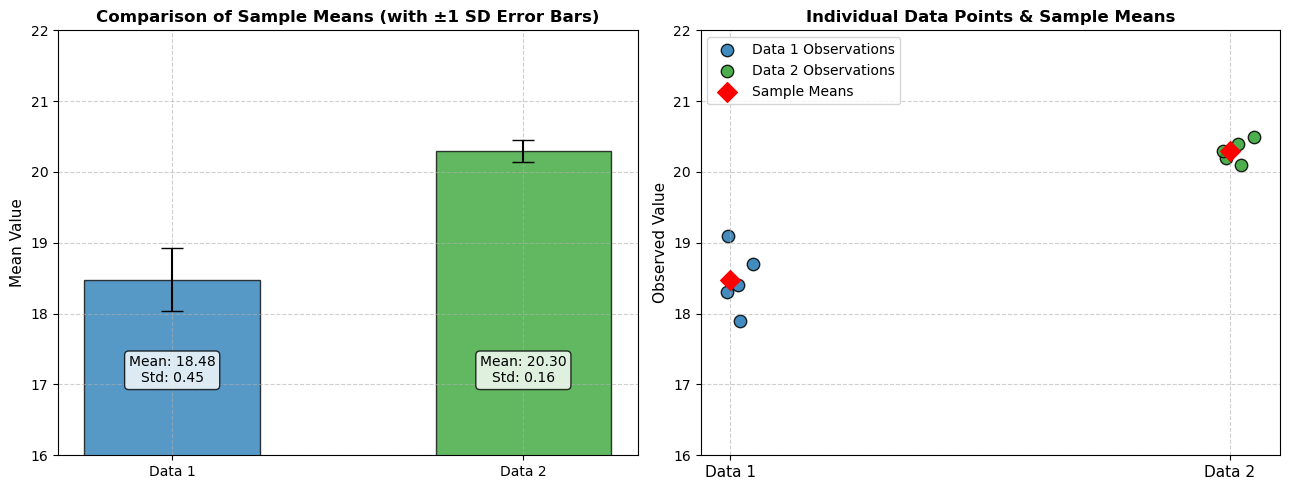

In [7]:
# Set plot styling and figure layout
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Bar Chart of Means with Error Bars
bar_labels = ['Data 1', 'Data 2']
bar_means = [mean1, mean2]
bar_stds = [std1, std2]
bar_colors = ['#1f77b4', '#2ca02c']

axes[0].bar(bar_labels, bar_means, yerr=bar_stds, capsize=8, color=bar_colors, alpha=0.75, edgecolor='black', width=0.5)
axes[0].set_title('Comparison of Sample Means (with ±1 SD Error Bars)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Value', fontsize=11)
axes[0].set_ylim(16, 22)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Annotate values on bars
axes[0].text(0, 17.2, f"Mean: {mean1:.2f}\nStd: {std1:.2f}", ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8), fontsize=10)
axes[0].text(1, 17.2, f"Mean: {mean2:.2f}\nStd: {std2:.2f}", ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8), fontsize=10)

# Subplot 2: Individual Observations and Group Means
np.random.seed(42)
jitter_1 = np.random.normal(0, 0.03, size=n1)
jitter_2 = np.random.normal(1, 0.03, size=n2)

axes[1].scatter(jitter_1, data1, color='#1f77b4', s=80, alpha=0.85, edgecolors='black', label='Data 1 Observations')
axes[1].scatter(jitter_2, data2, color='#2ca02c', s=80, alpha=0.85, edgecolors='black', label='Data 2 Observations')
axes[1].scatter([0, 1], [mean1, mean2], color='red', marker='D', s=100, zorder=5, label='Sample Means')

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(bar_labels, fontsize=11)
axes[1].set_title('Individual Data Points & Sample Means', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Observed Value', fontsize=11)
axes[1].set_ylim(16, 22)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()
